# Visual-language assistant using DeepSeek-VL2 and OpenVINO

DeepSeek-VL2 is an advanced series of large Mixture-of-Experts (MoE) Vision-Language models. . DeepSeek-VL2 demonstrates superior capabilities across various tasks, including but not limited to visual question answering, optical character recognition, document/table/chart understanding, and visual grounding.

More details can be found in the [paper](https://arxiv.org/abs/2412.10302) and original [repository](https://github.com/deepseek-ai/DeepSeek-VL2).

In this tutorial we consider how to convert and run DeepSeek-VL2 models using [OpenVINO](https://github.com/openvinotoolkit/openvino) and optimize it using [NNCF](https://github.com/openvinotoolkit/nncf).

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Convert model to OpenVINO Intermediate Representation](#Convert-model-to-OpenVINO-Intermediate-Representation)
    - [Compress model weights to 4-bit](#Compress-model-weights-to-4-bit)
    - [Prepare inference pipeline](#Prepare-inference-pipeline)
- [Run model inference](#Run-model-inference)
    - [Visual Grounding](#Visual-Grounding)
    - [Grounding Conversation](#Grounding-Conversation)
    - [Visual Question Answering](#Visual-Question-Answering)
- [Interactive demo](#Interactive-demo)


### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/deepseek-vl2/deepseek-vl2.ipynb" />


## Prerequisites
[back to top ⬆️](#Table-of-contents:)


In [1]:
import requests
from pathlib import Path

utility_files = ["cmd_helper.py", "notebook_utils.py", "pip_helper.py"]
base_utility_url = "https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/"

for utility in utility_files:
    if not Path(utility).exists():
        r = requests.get(base_utility_url + utility)
        with open(utility, "w", encoding="utf-8") as f:
            f.write(r.text)

helper_files = ["ov_deepseek_vl_helper.py", "modeling_helper.py", "gradio_helper.py"]
base_helper_url = "https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/notebooks/deepseek-vl2/"

for helper in helper_files:
    if not Path(helper).exists():
        r = requests.get(base_helper_url + helper)
        with open(helper, "w", encoding="utf-8") as f:
            f.write(r.text)

In [2]:
from pip_helper import pip_install
import platform

pip_install("-U", "openvino>=2025.0", "nncf>=2.15")
pip_install(
    "-q",
    "torch>=2.1",
    "torchvision",
    "gradio>=4.19",
    "einops",
    "transformers>=4.48.2",
    "timm>=0.9.16",
    "accelerate",
    "sentencepiece",
    "attrdict",
    "mdtex2html",
    "pypinyin",
    "tiktoken",
    "tqdm",
    "colorama",
    "Pygments",
    "markdown",
    "--extra-index-url",
    "https://download.pytorch.org/whl/cpu",
)

if platform.system() == "Darwin":
    pip_install("numpy<2.0")

  Using cached openvino-2025.2.0-19140-cp312-cp312-macosx_11_0_arm64.whl.metadata (12 kB)
Using cached openvino-2025.2.0-19140-cp312-cp312-macosx_11_0_arm64.whl (31.1 MB)
  Attempting uninstall: openvino
    Found existing installation: openvino 2025.0.0
    Uninstalling openvino-2025.0.0:
      Successfully uninstalled openvino-2025.0.0


In [3]:
from ov_deepseek_vl_helper import prepare_model_repo

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("deepseek-vl2.ipynb")

prepare_model_repo()

## Convert model to OpenVINO Intermediate Representation
[back to top ⬆️](#Table-of-contents:)


DeepSeek-VL2 is PyTorch model. OpenVINO supports PyTorch models via conversion to OpenVINO Intermediate Representation (IR). [OpenVINO model conversion API](https://docs.openvino.ai/2024/openvino-workflow/model-preparation.html#convert-a-model-with-python-convert-model) should be used for these purposes. `ov.convert_model` function accepts original PyTorch model instance and example input for tracing and returns `ov.Model` representing this model in OpenVINO framework. Converted model can be used for saving on disk using `ov.save_model` function or directly loading on device using `core.complie_model`. 

The script `ov_deepseek_vl_helper.py` contains helper function for model conversion, please check its content if you interested in conversion details.

<details>
  <summary><b>Click here for more detailed explanation of conversion steps</b></summary>
DeepSeek-VL2 is autoregressive transformer generative model, it means that each next model step depends from model output from previous step. The generation approach is based on the assumption that the probability distribution of a word sequence can be decomposed into the product of conditional next word distributions. In other words, model predicts the next token in the loop guided by previously generated tokens until the stop-condition will be not reached (generated sequence of maximum length or end of string token obtained). The way the next token will be selected over predicted probabilities is driven by the selected decoding methodology. You can find more information about the most popular decoding methods in this <a href="https://huggingface.co/blog/how-to-generate">blog</a>. The entry point for the generation process for models from the Hugging Face Transformers library is the `generate` method. You can find more information about its parameters and configuration in the  <a href="https://huggingface.co/docs/transformers/v4.26.1/en/main_classes/text_generation#transformers.GenerationMixin.generate">documentation</a>. To preserve flexibility in the selection decoding methodology, we will convert only model inference for one step.

DeepSeek-VL2 model consists of 3 parts:

* **Vision Model** for encoding input images into embedding space.
* **Embedding Model** for conversion input text tokens into embedding space.
* **Language Model** for generation answer based on input embeddings provided by Image Encoder and Input Embedding models.

</details>


### Compress model weights to 4-bit
[back to top ⬆️](#Table-of-contents:)


For reducing memory consumption, weights compression optimization can be applied using [NNCF](https://github.com/openvinotoolkit/nncf). 

<details>
    <summary><b>Click here for more details about weight compression</b></summary>
Weight compression aims to reduce the memory footprint of a model. It can also lead to significant performance improvement for large memory-bound models, such as Large Language Models (LLMs). LLMs and other models, which require extensive memory to store the weights during inference, can benefit from weight compression in the following ways:

* enabling the inference of exceptionally large models that cannot be accommodated in the memory of the device;

* improving the inference performance of the models by reducing the latency of the memory access when computing the operations with weights, for example, Linear layers.

[Neural Network Compression Framework (NNCF)](https://github.com/openvinotoolkit/nncf) provides 4-bit / 8-bit mixed weight quantization as a compression method primarily designed to optimize LLMs. The main difference between weights compression and full model quantization (post-training quantization) is that activations remain floating-point in the case of weights compression which leads to a better accuracy. Weight compression for LLMs provides a solid inference performance improvement which is on par with the performance of the full model quantization. In addition, weight compression is data-free and does not require a calibration dataset, making it easy to use.

`nncf.compress_weights` function can be used for performing weights compression. The function accepts an OpenVINO model and other compression parameters. Compared to INT8 compression, INT4 compression improves performance even more, but introduces a minor drop in prediction quality.

More details about weights compression, can be found in [OpenVINO documentation](https://docs.openvino.ai/2024/openvino-workflow/model-optimization-guide/weight-compression.html).
</details>

In [4]:
from ov_deepseek_vl_helper import model_ids
import ipywidgets as widgets

model_selector = widgets.Dropdown(options=model_ids, value=model_ids[0], description="Model")

model_selector

Dropdown(description='Model', options=('deepseek-ai/deepseek-vl2-tiny', 'deepseek-ai/deepseek-vl2-small'), val…

In [7]:
from huggingface_hub import login
import getpass

# Ask user for their token securely
hf_token = getpass.getpass("Enter your Hugging Face token: ")

# Log in to HF Hub
login(token=hf_token)

Enter your Hugging Face token:  ········


In [5]:
to_compress = widgets.Checkbox(value=True, description="Compression")
to_compress

Checkbox(value=True, description='Compression')

In [8]:
from ov_deepseek_vl_helper import convert_deepseek_vl

# uncomment the line to see conversion code
# ??convert_deepseek_vl

In [9]:
import nncf

quantization_config = None

if to_compress.value:
    quantization_config = {
        "vision": {"mode": nncf.CompressWeightsMode.INT8_ASYM},
        "llm": {"mode": nncf.CompressWeightsMode.INT4_SYM, "group_size": 64 if "tiny" in model_selector.value else -1, "ratio": 1.0},
    }

model_path = Path(model_selector.value.split("/")[-1]) / ("FP16" if not to_compress.value else "INT4")

convert_deepseek_vl(model_selector.value, model_path=model_path, quantization_config=quantization_config)

Python version is above 3.10, patching the collections module.
⌛ deepseek-ai/deepseek-vl2-tiny conversion started. Be patient, it may takes some time.
⌛ Load Original model


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-000001.safetensors:   0%|          | 0.00/6.74G [00:00<?, ?B/s]

DeepseekVLV2ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.
DeepseekV2ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `

...

Output()

✅ Weights compression finished


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


✅ deepseek-ai/deepseek-vl2-tiny model conversion finished. You can find results in deepseek-vl2-tiny/INT4


PosixPath('deepseek-vl2-tiny/INT4')

### Prepare inference pipeline
[back to top ⬆️](#Table-of-contents:)


`OVDeepseekVL2ForCausalLM` class defined in `ov_deepseek_vl_helper.py` represents model inference class. It accepts path to model directory and target device for inference, like original pipeline, `OVDeepseekVL2ForCausalLM` has `generate` method for getting answers. Besides that, it is compatible with original model processor class for preparing input.

In [16]:
from ov_deepseek_vl_helper import OVDeepseekVLV2ForCausalLM

# uncommet the line to see model class code
# ??OVDeepseekVLV2ForCausalLM

In [17]:
from notebook_utils import device_widget

device = device_widget(default="CPU", exclude=["NPU"])

device

Dropdown(description='Device:', options=('CPU', 'AUTO'), value='CPU')

In [ ]:
from deepseek_vl2.models import DeepseekVLV2Processor

ov_model = OVDeepseekVLV2ForCausalLM(model_path, device.value)
processor = DeepseekVLV2Processor.from_pretrained(model_path)

## Run model inference
[back to top ⬆️](#Table-of-contents:)


Let's check model prediction for popular tasks.

In [ ]:
import PIL
import re
from deepseek_vl2.serve.app_modules.presets import BOX2COLOR


def parse_ref_bbox(response, image: PIL.Image.Image):
    try:
        image = image.copy()
        image_h, image_w = image.size
        draw = PIL.ImageDraw.Draw(image)

        ref = re.findall(r"<\|ref\|>.*?<\|/ref\|>", response)
        bbox = re.findall(r"<\|det\|>.*?<\|/det\|>", response)
        assert len(ref) == len(bbox)

        if len(ref) == 0:
            return None

        boxes, labels = [], []
        for box, label in zip(bbox, ref):
            box = box.replace("<|det|>", "").replace("<|/det|>", "")
            label = label.replace("<|ref|>", "").replace("<|/ref|>", "")
            box = box[1:-1]
            for onebox in re.findall(r"\[.*?\]", box):
                boxes.append(eval(onebox))
                labels.append(label)

        for indice, (box, label) in enumerate(zip(boxes, labels)):
            box = (
                int(box[0] / 999 * image_h),
                int(box[1] / 999 * image_w),
                int(box[2] / 999 * image_h),
                int(box[3] / 999 * image_w),
            )

            box_color = BOX2COLOR[indice % len(BOX2COLOR.keys())]
            box_width = 3
            draw.rectangle(box, outline=box_color, width=box_width)

            text_x = box[0]
            text_y = box[1] - 20
            text_color = box_color
            font = PIL.ImageFont.truetype("DeepSeek-VL2/deepseek_vl2/serve/assets/simsun.ttc", size=20)
            draw.text((text_x, text_y), label, font=font, fill=text_color)

        return image
    except Exception:
        return None

### Visual Grounding
[back to top ⬆️](#Table-of-contents:)


Visual Grounding (VG) aims to locate the most relevant object or region in an image, based on a natural language query. The query can be a phrase, a sentence, or even a multi-round dialogue. Model supports special pattern `<|ref|>{grounding object}</|ref|>` for identification of specified grounding object on image.

Grounding request: 
<|ref|>The giraffe at the back.<|/ref|>.


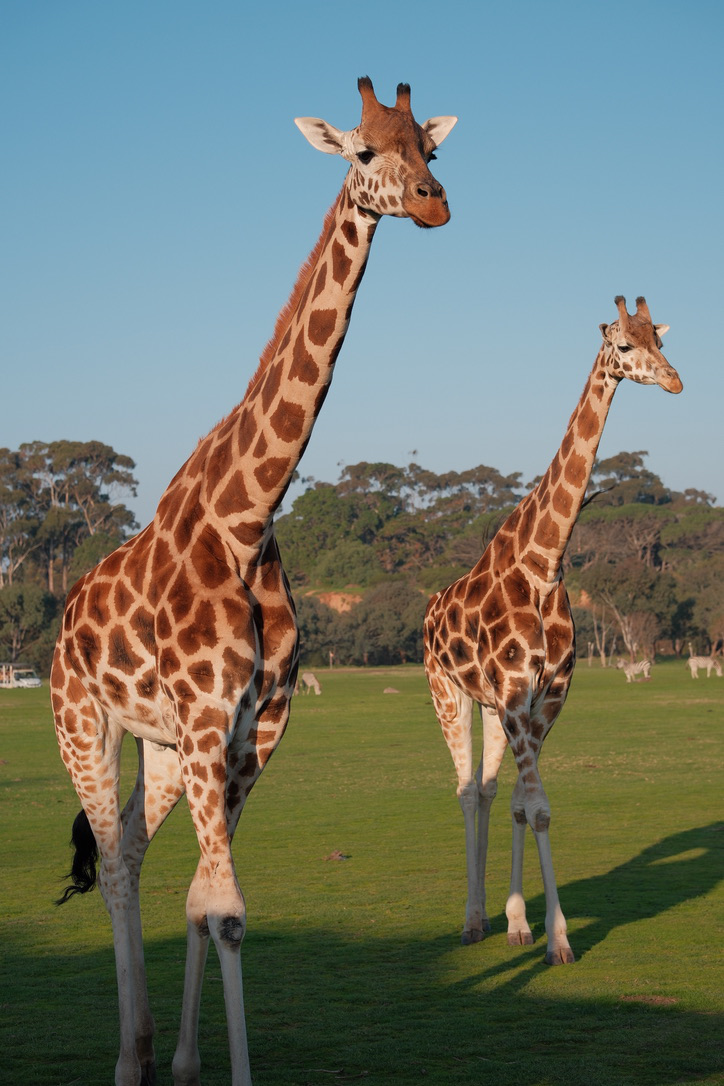

Answer:


RuntimeError: Exception from src/inference/src/cpp/infer_request.cpp:245:
Exception from src/bindings/python/src/pyopenvino/core/infer_request.hpp:54:
Caught exception: Exception from src/plugins/intel_cpu/src/node.cpp:785:
[CPU] Concat node with name '__module.model.model.layers.0.self_attn/aten::cat/Concat_2' Check 'TRShape::merge_into(output_shape, in_copy)' failed at src/core/shape_inference/include/concat_shape_inference.hpp:49:
While validating node 'opset1::Concat __module.model.model.layers.0.self_attn/aten::cat/Concat_2 (opset8::Gather Gather_577455[0]:f16[?,?,?,128], ie_internal_opset::RoPE __module.model.model.layers.0.self_attn/aten::add/Add_1[0]:f16[?,10,?,128]) -> (f16[?,10,?,128])' with friendly_name '__module.model.model.layers.0.self_attn/aten::cat/Concat_2':
Shape inference input shapes {{1,0,0,128},{1,10,1446,128}}
Argument shapes are inconsistent; they must have the same rank, and must have equal dimension everywhere except on the concatenation axis (axis 2).





In [15]:
from transformers import TextStreamer


def load_pil_images(conversations):
    """

    Args:
        conversations (list[dict[str, str]]): the conversations with a list of messages. An example is :
            [
                {
                    "role": "User",
                    "content": "<image>\nExtract all information from this image and convert them into markdown format.",
                    "images": ["./examples/table_datasets.png"]
                },
                {"role": "Assistant", "content": ""},
            ]

    Returns:
        pil_images (list[PIL.Image.Image]): the list of PIL images.

    """

    pil_images = []

    for message in conversations:
        if "images" not in message:
            continue

        for image_path in message["images"]:
            pil_img = PIL.Image.open(image_path)
            pil_img = pil_img.convert("RGB")
            pil_images.append(pil_img)

    return pil_images


conversation = [
    {
        "role": "<|User|>",
        "content": "<image>\n<|ref|>The giraffe at the back.<|/ref|>.",
        "images": ["DeepSeek-VL2/images/visual_grounding_1.jpeg"],
    },
    {"role": "<|Assistant|>", "content": ""},
]

pil_images = load_pil_images(conversation)
prepare_inputs = processor(conversations=conversation, images=pil_images, force_batchify=True, system_prompt="")

print(f"Grounding request: {conversation[0]['content'].replace('<image>', '')}")
display(pil_images[-1])
inputs_embeds = ov_model.prepare_inputs_embeds(**prepare_inputs)
print("Answer:")

# run the model to get the response
outputs = ov_model.language_model.generate(
    inputs_embeds=inputs_embeds,
    attention_mask=None,
    pad_token_id=processor.tokenizer.eos_token_id,
    bos_token_id=processor.tokenizer.bos_token_id,
    eos_token_id=processor.tokenizer.eos_token_id,
    past_key_values=None,
    input_ids=None,
    max_new_tokens=512,
    do_sample=False,
    use_cache=True,
    streamer=TextStreamer(processor.tokenizer, skip_special_tokens=True),
)

answer = processor.tokenizer.batch_decode(outputs, skip_special_tokens=False)

vg_image = parse_ref_bbox(answer[0], image=pil_images[-1])

if vg_image is not None:
    display(vg_image)

## Grounding Conversation
[back to top ⬆️](#Table-of-contents:)


It also support grounding in conversation context using special token <|grounding|>. That allow to answer questions about image content with additional finding relevant objects.

In [ ]:
conversation = [
    {
        "role": "<|User|>",
        "content": "<image>\n<|grounding|>I want to throw out the trash now, what should I do?.",
        "images": ["DeepSeek-VL2/images/grounding_conversation_1.jpeg"],
    },
    {"role": "<|Assistant|>", "content": ""},
]

pil_images = load_pil_images(conversation)
prepare_inputs = processor(conversations=conversation, images=pil_images, force_batchify=True, system_prompt="")
print(f"Grounding request: {conversation[0]['content'].replace('<image>', '')}")
display(pil_images[-1])

inputs_embeds = ov_model.prepare_inputs_embeds(**prepare_inputs)
print("Answer:")
# run the model to get the response
outputs = ov_model.language_model.generate(
    inputs_embeds=inputs_embeds,
    attention_mask=None,
    pad_token_id=processor.tokenizer.eos_token_id,
    bos_token_id=processor.tokenizer.bos_token_id,
    eos_token_id=processor.tokenizer.eos_token_id,
    past_key_values=None,
    input_ids=None,
    max_new_tokens=512,
    do_sample=False,
    use_cache=True,
    streamer=TextStreamer(processor.tokenizer, skip_special_tokens=True),
)

answer = processor.tokenizer.batch_decode(outputs, skip_special_tokens=False)

vg_image = parse_ref_bbox(answer[0], image=pil_images[-1])

if vg_image is not None:
    display(vg_image)

### Visual Question Answering
[back to top ⬆️](#Table-of-contents:)


Model can answer natural language questions based on images content. DeepSeek-VL2 offers significant advantages for Optical Character Recognition (OCR). It supports integration of contextual captioning with OCR that gives reach document processing capabilities.

In [ ]:
conversation = [
    {
        "role": "<|User|>",
        "content": "<image>\nDescribe each stage of this image in detail",
        "images": ["DeepSeek-VL2/images/vqa_1.jpg"],
    },
    {"role": "<|Assistant|>", "content": ""},
]

pil_images = load_pil_images(conversation)
prepare_inputs = processor(conversations=conversation, images=pil_images, force_batchify=True, system_prompt="")
print(f"Question: {conversation[0]['content'].replace('<image>', '')}")
display(pil_images[-1])
inputs_embeds = ov_model.prepare_inputs_embeds(**prepare_inputs)
print("Answer:")

# run the model to get the response
outputs = ov_model.language_model.generate(
    inputs_embeds=inputs_embeds,
    attention_mask=None,
    pad_token_id=processor.tokenizer.eos_token_id,
    bos_token_id=processor.tokenizer.bos_token_id,
    eos_token_id=processor.tokenizer.eos_token_id,
    past_key_values=None,
    input_ids=None,
    max_new_tokens=512,
    do_sample=False,
    use_cache=True,
    streamer=TextStreamer(processor.tokenizer, skip_special_tokens=True),
)

answer = processor.tokenizer.batch_decode(outputs, skip_special_tokens=False)

vg_image = parse_ref_bbox(answer[0], image=pil_images[-1])

if vg_image is not None:
    display(vg_image)

## Interactive demo
[back to top ⬆️](#Table-of-contents:)

In [ ]:
from gradio_helper import make_demo

demo = make_demo(ov_model, processor)

try:
    demo.launch(debug=True)
except Exception:
    demo.launch(debug=True, share=True)
# if you are launching remotely, specify server_name and server_port
# demo.launch(server_name='your server name', server_port='server port in int')
# Read more in the docs: https://gradio.app/docs/